# 04 — Hyperparameter Tuning with Nested Cross-Validation
**Ensemble Early Parkinson Detection Using Voice Biomarkers**

This notebook implements nested cross-validation for unbiased hyperparameter tuning:
- **Outer loop** (5-fold GroupKFold): Unbiased performance estimation
- **Inner loop** (5-fold GroupKFold): Hyperparameter selection via GridSearchCV

We tune each classifier using its best configuration from Notebook 03:
- All models use `class_weight='balanced'`
- SVM_RBF, SVM_Linear, Logistic_L1, Logistic_L2 → SVM-RFE features
- KNN, Random_Forest → RF-RFE features

Nested CV ensures that hyperparameter selection does not inflate our reported performance.

## 1. Setup

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time

from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupKFold, GridSearchCV
from imblearn.pipeline import Pipeline as ImbPipeline

from src.data_utils import load_parkinsons, get_X_y_groups, FEATURE_COLS
from src.eval_utils import (
    compute_metrics, results_to_dataframe, plot_confusion_matrix,
    plot_multiple_confusion_matrices
)
from src.pipeline_utils import build_pipeline, run_grouped_cv, run_nested_cv

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')

RANDOM_STATE = 42
N_OUTER = 5
N_INNER = 5

df = load_parkinsons()
X, y, groups = get_X_y_groups(df)
print(f'X: {X.shape}, y: {y.shape}, Subjects: {groups.nunique()}')

X: (195, 22), y: (195,), Subjects: 32


## 2. Define Best Feature Sets from Notebook 03

From our experiments:
- SVM-RFE features → best for SVM_RBF, SVM_Linear, Logistic_L1, Logistic_L2
- RF-RFE features → best for KNN, Random_Forest

In [3]:
# Best feature sets from Notebook 03
SVM_RFE_FEATURES = [
    'MDVP:RAP', 'MDVP:PPQ', 'Jitter:DDP', 'MDVP:APQ',
    'spread1', 'D2', 'MDVP:Jitter(%)', 'MDVP:Jitter(Abs)', 'NHR', 'PPE'
]

# Load RF-RFE features from saved results (or paste them here)
rf_rfe_ranking = pd.read_csv('../results/rf_rfe_ranking.csv')
RF_RFE_FEATURES = rf_rfe_ranking[rf_rfe_ranking['times_selected'] >= 3]['feature'].tolist()

print(f'SVM-RFE features ({len(SVM_RFE_FEATURES)}): {SVM_RFE_FEATURES}')
print(f'RF-RFE features ({len(RF_RFE_FEATURES)}): {RF_RFE_FEATURES}')

# Map each model to its best feature set
MODEL_FEATURE_MAP = {
    'SVM_RBF': SVM_RFE_FEATURES,
    'SVM_Linear': SVM_RFE_FEATURES,
    'KNN': RF_RFE_FEATURES,
    'Random_Forest': RF_RFE_FEATURES,
    'Logistic_L1': SVM_RFE_FEATURES,
    'Logistic_L2': SVM_RFE_FEATURES,
}

SVM-RFE features (10): ['MDVP:RAP', 'MDVP:PPQ', 'Jitter:DDP', 'MDVP:APQ', 'spread1', 'D2', 'MDVP:Jitter(%)', 'MDVP:Jitter(Abs)', 'NHR', 'PPE']
RF-RFE features (8): ['PPE', 'spread1', 'MDVP:APQ', 'MDVP:Fo(Hz)', 'spread2', 'Shimmer:APQ5', 'MDVP:Fhi(Hz)', 'D2']


## 3. Define Classifiers and Hyperparameter Grids

In [4]:
# Classifiers with class_weight='balanced' (except KNN which doesn't support it)
CLASSIFIERS = {
    'SVM_RBF': SVC(
        kernel='rbf', class_weight='balanced', probability=True, random_state=RANDOM_STATE
    ),
    'SVM_Linear': SVC(
        kernel='linear', class_weight='balanced', probability=True, random_state=RANDOM_STATE
    ),
    'KNN': KNeighborsClassifier(),
    'Random_Forest': RandomForestClassifier(
        class_weight='balanced', random_state=RANDOM_STATE
    ),
    'Logistic_L1': LogisticRegression(
        penalty='l1', solver='saga', max_iter=5000,
        class_weight='balanced', random_state=RANDOM_STATE
    ),
    'Logistic_L2': LogisticRegression(
        penalty='l2', solver='lbfgs', max_iter=5000,
        class_weight='balanced', random_state=RANDOM_STATE
    ),
}

# Hyperparameter grids — keys use 'clf__' prefix for pipeline
PARAM_GRIDS = {
    'SVM_RBF': {
        'clf__C': [0.01, 0.1, 1, 10, 100],
        'clf__gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1],
    },
    'SVM_Linear': {
        'clf__C': [0.001, 0.01, 0.1, 1, 10, 100],
    },
    'KNN': {
        'clf__n_neighbors': [3, 5, 7, 9, 11, 15],
        'clf__weights': ['uniform', 'distance'],
        'clf__metric': ['euclidean', 'manhattan', 'minkowski'],
    },
    'Random_Forest': {
        'clf__n_estimators': [50, 100, 200, 300],
        'clf__max_depth': [None, 3, 5, 10, 15],
        'clf__min_samples_split': [2, 5, 10],
        'clf__min_samples_leaf': [1, 2, 4],
    },
    'Logistic_L1': {
        'clf__C': [0.001, 0.01, 0.1, 1, 10, 100],
    },
    'Logistic_L2': {
        'clf__C': [0.001, 0.01, 0.1, 1, 10, 100],
    },
}

# Print grid sizes
for name, grid in PARAM_GRIDS.items():
    n_combos = 1
    for vals in grid.values():
        n_combos *= len(vals)
    print(f'{name}: {n_combos} hyperparameter combinations')

SVM_RBF: 30 hyperparameter combinations
SVM_Linear: 6 hyperparameter combinations
KNN: 36 hyperparameter combinations
Random_Forest: 180 hyperparameter combinations
Logistic_L1: 6 hyperparameter combinations
Logistic_L2: 6 hyperparameter combinations


## 4. Run Nested Cross-Validation

For each model:
1. Select its best feature set
2. Build a pipeline (StandardScaler → Classifier)
3. Run nested CV: outer 5-fold GroupKFold × inner 5-fold GroupKFold GridSearchCV
4. Collect unbiased performance estimates and best hyperparameters per fold

In [5]:
nested_results = {}

for name, clf in CLASSIFIERS.items():
    features = MODEL_FEATURE_MAP[name]
    X_subset = X[features]
    param_grid = PARAM_GRIDS[name]
    
    pipe = build_pipeline(clf)
    
    print(f'\n{"="*60}')
    print(f'  Tuning {name} ({len(features)} features)')
    print(f'  Grid size: {param_grid}')
    print(f'{"="*60}')
    
    start = time.time()
    results = run_nested_cv(
        pipeline=pipe,
        param_grid=param_grid,
        X=X_subset, y=y, groups=groups,
        outer_splits=N_OUTER,
        inner_splits=N_INNER,
        scoring='balanced_accuracy',
        n_jobs=-1
    )
    elapsed = time.time() - start
    
    nested_results[name] = results
    
    print(f'  Time: {elapsed:.1f}s')
    print(f'  Balanced Accuracy: {results["mean_metrics"]["balanced_accuracy"]:.4f} '
          f'± {results["std_metrics"]["balanced_accuracy"]:.4f}')
    print(f'  Sensitivity: {results["mean_metrics"]["sensitivity"]:.4f}')
    print(f'  Specificity: {results["mean_metrics"]["specificity"]:.4f}')
    print(f'  Best params per fold:')
    for i, params in enumerate(results['best_params']):
        print(f'    Fold {i+1}: {params}')

print('\nAll models tuned!')


  Tuning SVM_RBF (10 features)
  Grid size: {'clf__C': [0.01, 0.1, 1, 10, 100], 'clf__gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1]}


/Users/achintyashah/Desktop/parkinsons-detection/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:2480: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/Users/achintyashah/Desktop/parkinsons-detection/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:2480: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/Users/achintyashah/Desktop/parkinsons-detection/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:2480: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/Users/achintyashah/Desktop/parkinsons-detection/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:2480: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/Users/achintyashah/Desktop/parkinsons-detection/.venv/lib/python3.9/sit

  Time: 3.3s
  Balanced Accuracy: 0.6706 ± 0.1223
  Sensitivity: 0.7579
  Specificity: 0.5833
  Best params per fold:
    Fold 1: {'clf__C': 100, 'clf__gamma': 0.001}
    Fold 2: {'clf__C': 10, 'clf__gamma': 0.001}
    Fold 3: {'clf__C': 10, 'clf__gamma': 0.01}
    Fold 4: {'clf__C': 100, 'clf__gamma': 0.01}
    Fold 5: {'clf__C': 100, 'clf__gamma': 'scale'}

  Tuning SVM_Linear (10 features)
  Grid size: {'clf__C': [0.001, 0.01, 0.1, 1, 10, 100]}


/Users/achintyashah/Desktop/parkinsons-detection/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:2480: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/Users/achintyashah/Desktop/parkinsons-detection/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:2480: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/Users/achintyashah/Desktop/parkinsons-detection/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:2480: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/Users/achintyashah/Desktop/parkinsons-detection/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:2480: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/Users/achintyashah/Desktop/parkinsons-detection/.venv/lib/python3.9/sit

  Time: 0.3s
  Balanced Accuracy: 0.7193 ± 0.1778
  Sensitivity: 0.7719
  Specificity: 0.6667
  Best params per fold:
    Fold 1: {'clf__C': 1}
    Fold 2: {'clf__C': 0.1}
    Fold 3: {'clf__C': 1}
    Fold 4: {'clf__C': 10}
    Fold 5: {'clf__C': 0.01}

  Tuning KNN (8 features)
  Grid size: {'clf__n_neighbors': [3, 5, 7, 9, 11, 15], 'clf__weights': ['uniform', 'distance'], 'clf__metric': ['euclidean', 'manhattan', 'minkowski']}


...

/Users/achintyashah/Desktop/parkinsons-detection/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:409: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/Users/achintyashah/Desktop/parkinsons-detection/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:409: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/Users/achintyashah/Desktop/parkinsons-detection/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:409: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/Users/achintyashah/Desktop/parkinsons-detection/.venv/lib/python3.9/site

  Time: 54.1s
  Balanced Accuracy: 0.6776 ± 0.1793
  Sensitivity: 0.8720
  Specificity: 0.4833
  Best params per fold:
    Fold 1: {'clf__max_depth': None, 'clf__min_samples_leaf': 2, 'clf__min_samples_split': 10, 'clf__n_estimators': 50}
    Fold 2: {'clf__max_depth': 3, 'clf__min_samples_leaf': 2, 'clf__min_samples_split': 2, 'clf__n_estimators': 50}
    Fold 3: {'clf__max_depth': None, 'clf__min_samples_leaf': 4, 'clf__min_samples_split': 10, 'clf__n_estimators': 200}
    Fold 4: {'clf__max_depth': None, 'clf__min_samples_leaf': 4, 'clf__min_samples_split': 2, 'clf__n_estimators': 200}
    Fold 5: {'clf__max_depth': 5, 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 10, 'clf__n_estimators': 50}

  Tuning Logistic_L1 (10 features)
  Grid size: {'clf__C': [0.001, 0.01, 0.1, 1, 10, 100]}


/Users/achintyashah/Desktop/parkinsons-detection/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:2480: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/Users/achintyashah/Desktop/parkinsons-detection/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:2480: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/Users/achintyashah/Desktop/parkinsons-detection/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:2480: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/Users/achintyashah/Desktop/parkinsons-detection/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:2480: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/Users/achintyashah/Desktop/parkinsons-detection/.venv/lib/python3.9/sit

  Time: 0.6s
  Balanced Accuracy: 0.7368 ± 0.1539
  Sensitivity: 0.7737
  Specificity: 0.7000
  Best params per fold:
    Fold 1: {'clf__C': 0.1}
    Fold 2: {'clf__C': 0.1}
    Fold 3: {'clf__C': 1}
    Fold 4: {'clf__C': 1}
    Fold 5: {'clf__C': 1}

  Tuning Logistic_L2 (10 features)
  Grid size: {'clf__C': [0.001, 0.01, 0.1, 1, 10, 100]}
  Time: 0.2s
  Balanced Accuracy: 0.7558 ± 0.1498
  Sensitivity: 0.7784
  Specificity: 0.7333
  Best params per fold:
    Fold 1: {'clf__C': 1}
    Fold 2: {'clf__C': 0.1}
    Fold 3: {'clf__C': 1}
    Fold 4: {'clf__C': 0.1}
    Fold 5: {'clf__C': 0.1}

All models tuned!


/Users/achintyashah/Desktop/parkinsons-detection/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:2480: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/Users/achintyashah/Desktop/parkinsons-detection/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:2480: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/Users/achintyashah/Desktop/parkinsons-detection/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:2480: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/Users/achintyashah/Desktop/parkinsons-detection/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:2480: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/Users/achintyashah/Desktop/parkinsons-detection/.venv/lib/python3.9/sit

## 5. Tuned Results Comparison

In [6]:
# Build comparison table
tuned_summary = {name: res['mean_metrics'] for name, res in nested_results.items()}
tuned_df = results_to_dataframe(tuned_summary)

tuned_std = {name: res['std_metrics'] for name, res in nested_results.items()}
tuned_std_df = results_to_dataframe(tuned_std)

print('--- Tuned Results (Nested CV, Subject-wise GroupKFold) ---\n')
print(tuned_df.to_string())
print('\n--- Standard Deviations ---\n')
print(tuned_std_df.to_string())

--- Tuned Results (Nested CV, Subject-wise GroupKFold) ---

               accuracy  balanced_accuracy  sensitivity  specificity  precision      f1     mcc  auc_roc
Model                                                                                                   
SVM_RBF          0.7112             0.6706       0.7579       0.5833     0.8447  0.7925  0.3118   0.8123
SVM_Linear       0.7512             0.7193       0.7719       0.6667     0.8824  0.8197  0.3920   0.8403
KNN              0.8211             0.7175       0.9184       0.5167     0.8595  0.8850  0.4267   0.9127
Random_Forest    0.7789             0.6776       0.8720       0.4833     0.8440  0.8546  0.3311   0.8862
Logistic_L1      0.7601             0.7368       0.7737       0.7000     0.8991  0.8236  0.4300   0.8710
Logistic_L2      0.7716             0.7558       0.7784       0.7333     0.9005  0.8298  0.4629   0.8671

--- Standard Deviations ---

               accuracy  balanced_accuracy  sensitivity  specificity  

In [7]:
# Combined mean ± std table
combined_rows = []
for name in tuned_df.index:
    row = {'Model': name, 'Features': ', '.join(MODEL_FEATURE_MAP[name][:3]) + '...'}
    for metric in ['balanced_accuracy', 'sensitivity', 'specificity', 'f1', 'mcc', 'auc_roc']:
        mean_val = tuned_df.loc[name, metric]
        std_val = tuned_std_df.loc[name, metric]
        if mean_val is not None and not np.isnan(mean_val):
            row[metric] = f'{mean_val:.4f} ± {std_val:.4f}'
        else:
            row[metric] = 'N/A'
    combined_rows.append(row)

combined_df = pd.DataFrame(combined_rows).set_index('Model')
print('--- Tuned Results: Mean ± Std ---\n')
combined_df

--- Tuned Results: Mean ± Std ---



,Features,balanced_accuracy,sensitivity,specificity,f1,mcc,auc_roc
Model,,,,,,,
SVM_RBF,"MDVP:RAP, MDVP:PPQ, Jitter:DDP...",0.6706 ± 0.1223,0.7579 ± 0.1281,0.5833 ± 0.2357,0.7925 ± 0.0887,0.3118 ± 0.2019,0.8123 ± 0.1368
SVM_Linear,"MDVP:RAP, MDVP:PPQ, Jitter:DDP...",0.7193 ± 0.1778,0.7719 ± 0.1240,0.6667 ± 0.3162,0.8197 ± 0.1047,0.3920 ± 0.3135,0.8403 ± 0.1764
KNN,"PPE, spread1, MDVP:APQ...",0.7175 ± 0.1472,0.9184 ± 0.0324,0.5167 ± 0.3266,0.8850 ± 0.0279,0.4267 ± 0.2700,0.9127 ± 0.0552
Random_Forest,"PPE, spread1, MDVP:APQ...",0.6776 ± 0.1793,0.8720 ± 0.0697,0.4833 ± 0.3590,0.8546 ± 0.0618,0.3311 ± 0.3321,0.8862 ± 0.0694
Logistic_L1,"MDVP:RAP, MDVP:PPQ, Jitter:DDP...",0.7368 ± 0.1539,0.7737 ± 0.1460,0.7000 ± 0.3055,0.8236 ± 0.0998,0.4300 ± 0.2815,0.8710 ± 0.1274
Logistic_L2,"MDVP:RAP, MDVP:PPQ, Jitter:DDP...",0.7558 ± 0.1498,0.7784 ± 0.1415,0.7333 ± 0.2494,0.8298 ± 0.1119,0.4629 ± 0.2625,0.8671 ± 0.1379


## 6. Tuned vs Untuned Comparison

Compare against the best untuned results from Notebook 03 to see how much tuning helps.

In [8]:
# Load Notebook 03 best configs
nb03_best = pd.read_csv('../results/best_configs_per_model.csv')

# Build comparison
comparison_rows = []
for name in CLASSIFIERS.keys():
    nb03_row = nb03_best[nb03_best['model'] == name].iloc[0]
    
    row = {
        'Model': name,
        'Untuned BA': nb03_row['balanced_accuracy'],
        'Tuned BA': nested_results[name]['mean_metrics']['balanced_accuracy'],
        'Untuned Sens': nb03_row['sensitivity'],
        'Tuned Sens': nested_results[name]['mean_metrics']['sensitivity'],
        'Untuned Spec': nb03_row['specificity'],
        'Tuned Spec': nested_results[name]['mean_metrics']['specificity'],
    }
    row['BA Change'] = row['Tuned BA'] - row['Untuned BA']
    comparison_rows.append(row)

comparison_df = pd.DataFrame(comparison_rows).set_index('Model').round(4)
print('--- Tuned vs Untuned (Best Config from NB03) ---\n')
print(comparison_df.to_string())

--- Tuned vs Untuned (Best Config from NB03) ---

               Untuned BA  Tuned BA  Untuned Sens  Tuned Sens  Untuned Spec  Tuned Spec  BA Change
Model                                                                                             
SVM_RBF            0.7956    0.6706        0.7579      0.7579        0.8333      0.5833    -0.1250
SVM_Linear         0.7026    0.7193        0.7719      0.7719        0.6333      0.6667     0.0167
KNN                0.7342    0.7175        0.9184      0.9184        0.5500      0.5167    -0.0167
Random_Forest      0.6995    0.6776        0.9324      0.8720        0.4667      0.4833    -0.0219
Logistic_L1        0.7497    0.7368        0.7995      0.7737        0.7000      0.7000    -0.0129
Logistic_L2        0.7432    0.7558        0.7864      0.7784        0.7000      0.7333     0.0126


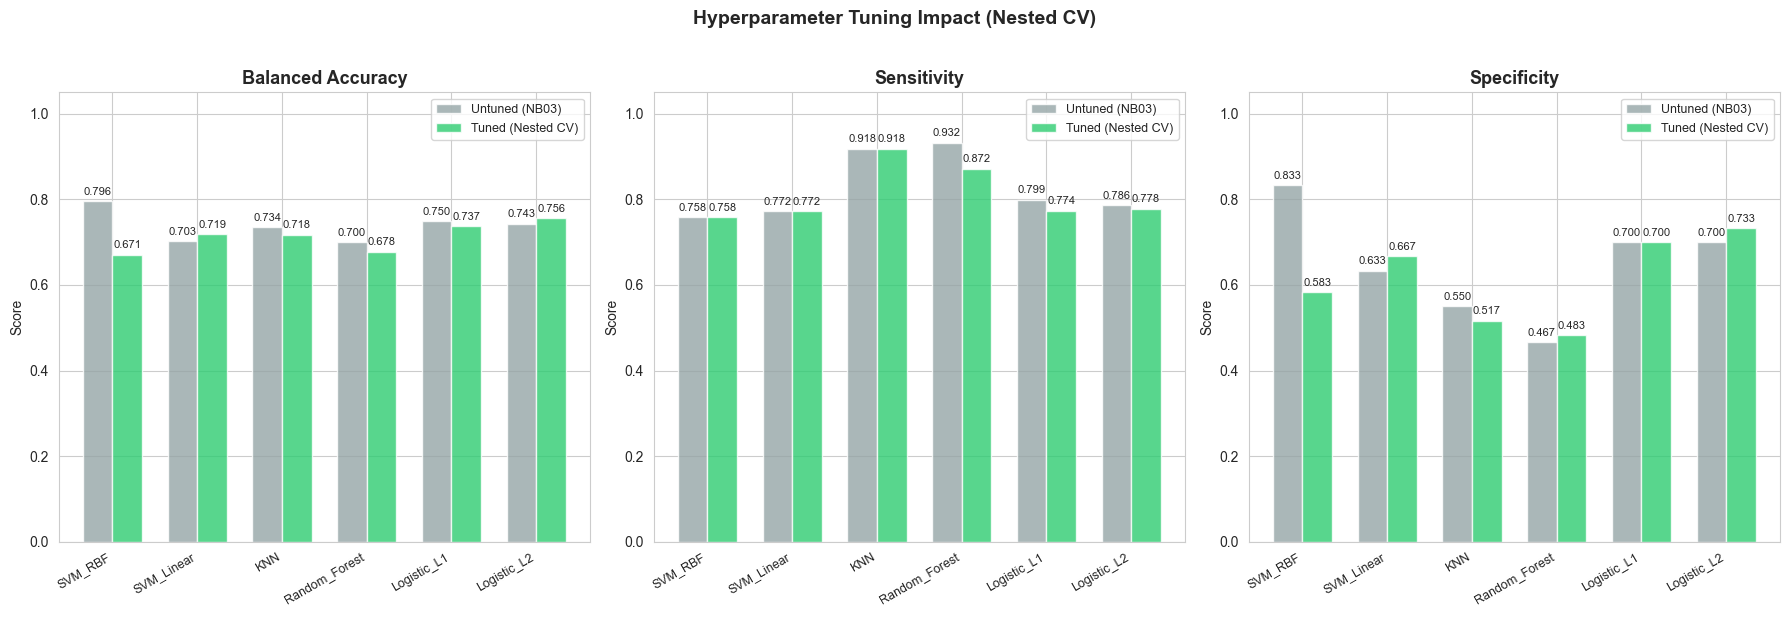

In [9]:
# Visualize tuned vs untuned
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
metrics_pairs = [
    ('Untuned BA', 'Tuned BA', 'Balanced Accuracy'),
    ('Untuned Sens', 'Tuned Sens', 'Sensitivity'),
    ('Untuned Spec', 'Tuned Spec', 'Specificity'),
]

model_names = comparison_df.index.tolist()
x = np.arange(len(model_names))
width = 0.35

for ax, (untuned_col, tuned_col, title) in zip(axes, metrics_pairs):
    bars1 = ax.bar(x - width/2, comparison_df[untuned_col], width,
                   label='Untuned (NB03)', color='#95a5a6', alpha=0.8)
    bars2 = ax.bar(x + width/2, comparison_df[tuned_col], width,
                   label='Tuned (Nested CV)', color='#2ecc71', alpha=0.8)
    
    ax.set_ylabel('Score')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(model_names, rotation=30, ha='right', fontsize=9)
    ax.legend(fontsize=9)
    ax.set_ylim(0, 1.05)
    
    # Annotate
    for bars in [bars1, bars2]:
        for bar in bars:
            h = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.01, f'{h:.3f}',
                    ha='center', va='bottom', fontsize=8)

plt.suptitle('Hyperparameter Tuning Impact (Nested CV)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../figures/tuned_vs_untuned.png', bbox_inches='tight')
plt.show()

## 7. Hyperparameter Stability Analysis

Check whether the same hyperparameters are selected across outer folds. Stable selection → reliable tuning. Unstable → model is sensitive to the data split.

In [10]:
for name, results in nested_results.items():
    print(f'\n{"="*50}')
    print(f'  {name} — Best Params Per Fold')
    print(f'{"="*50}')
    
    params_df = pd.DataFrame(results['best_params'])
    print(params_df.to_string(index=True))
    
    # Check stability: how many unique values per parameter
    print('\n  Stability (unique values per parameter):')
    for col in params_df.columns:
        n_unique = params_df[col].nunique()
        most_common = params_df[col].mode()[0]
        print(f'    {col}: {n_unique} unique values, most common = {most_common}')


  SVM_RBF — Best Params Per Fold
   clf__C clf__gamma
0     100      0.001
1      10      0.001
2      10       0.01
3     100       0.01
4     100      scale

  Stability (unique values per parameter):
    clf__C: 2 unique values, most common = 100
    clf__gamma: 3 unique values, most common = 0.001

  SVM_Linear — Best Params Per Fold
   clf__C
0    1.00
1    0.10
2    1.00
3   10.00
4    0.01

  Stability (unique values per parameter):
    clf__C: 4 unique values, most common = 1.0

  KNN — Best Params Per Fold
  clf__metric  clf__n_neighbors clf__weights
0   euclidean                 5      uniform
1   euclidean                15      uniform
2   euclidean                15      uniform
3   euclidean                 5      uniform
4   euclidean                15      uniform

  Stability (unique values per parameter):
    clf__metric: 1 unique values, most common = euclidean
    clf__n_neighbors: 2 unique values, most common = 15
    clf__weights: 1 unique values, most common = u

## 8. Per-Fold Performance Analysis

In [11]:
# Show per-fold metrics for the top models
for name in ['SVM_RBF', 'Logistic_L1', 'KNN', 'Random_Forest']:
    print(f'\n--- {name} Per-Fold Metrics ---')
    fold_df = pd.DataFrame(nested_results[name]['fold_metrics'])
    fold_df.index = [f'Fold {i+1}' for i in range(len(fold_df))]
    fold_df.loc['Mean'] = fold_df.mean()
    fold_df.loc['Std'] = fold_df.iloc[:-1].std()
    print(fold_df.round(4).to_string())


--- SVM_RBF Per-Fold Metrics ---
        accuracy  balanced_accuracy  sensitivity  specificity  precision      f1     mcc  auc_roc
Fold 1    0.7568             0.8548       0.7097       1.0000     1.0000  0.8302  0.5328   0.9677
Fold 2    0.7838             0.7533       0.8400       0.6667     0.8400  0.8400  0.5067   0.9100
Fold 3    0.7297             0.5699       0.8065       0.3333     0.8621  0.8333  0.1252   0.8280
Fold 4    0.5238             0.5167       0.5333       0.5000     0.7273  0.6154  0.0302   0.5694
Fold 5    0.7619             0.6583       0.9000       0.4167     0.7941  0.8438  0.3643   0.7861
Mean      0.7112             0.6706       0.7579       0.5833     0.8447  0.7925  0.3118   0.8123
Std       0.1065             0.1367       0.1432       0.2635     0.1010  0.0992  0.2257   0.1530

--- Logistic_L1 Per-Fold Metrics ---
        accuracy  balanced_accuracy  sensitivity  specificity  precision      f1     mcc  auc_roc
Fold 1    0.7297             0.8387       0.67

## 9. Confusion Matrices for Tuned Models

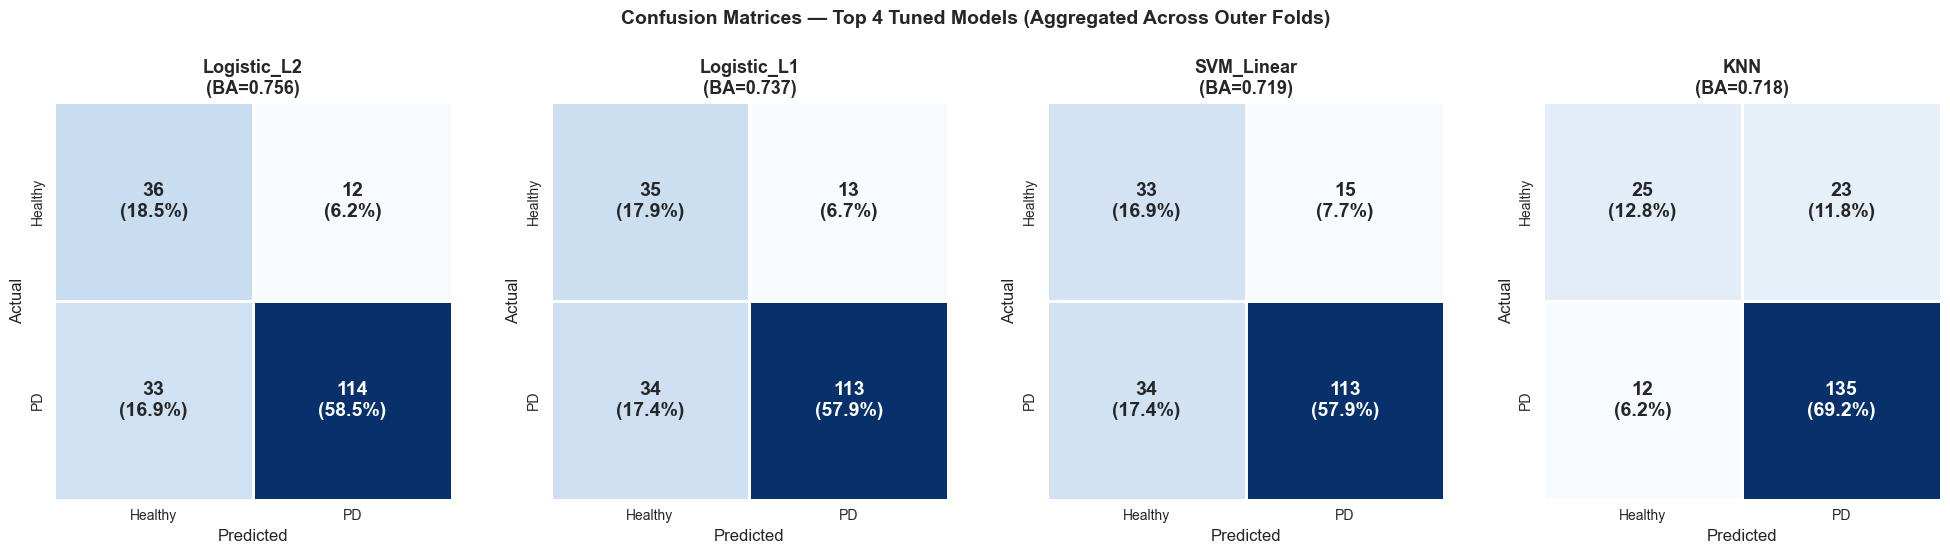

In [12]:
# Aggregate predictions across outer folds for each model
cm_dict = {}
for name, results in nested_results.items():
    all_yt = np.concatenate(results['y_trues'])
    all_yp = np.concatenate(results['y_preds'])
    cm_dict[name] = (all_yt, all_yp)

# Plot top 4 models
top_models = sorted(nested_results.keys(),
                    key=lambda n: nested_results[n]['mean_metrics']['balanced_accuracy'],
                    reverse=True)[:4]

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, name in zip(axes, top_models):
    yt, yp = cm_dict[name]
    ba = nested_results[name]['mean_metrics']['balanced_accuracy']
    plot_confusion_matrix(yt, yp, title=f'{name}\n(BA={ba:.3f})', ax=ax)

plt.suptitle('Confusion Matrices — Top 4 Tuned Models (Aggregated Across Outer Folds)',
             fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.savefig('../figures/tuned_confusion_matrices.png', bbox_inches='tight')
plt.show()

## 10. Select Models for Stacking Ensemble

Choose diverse base learners for the stacking ensemble. We want:
- Different model families (kernel, instance-based, tree, linear)
- Reasonable individual performance
- Partially uncorrelated errors

In [13]:
# Rank models
ranking = []
for name, results in nested_results.items():
    ranking.append({
        'Model': name,
        'Family': {
            'SVM_RBF': 'Kernel', 'SVM_Linear': 'Linear',
            'KNN': 'Instance-based', 'Random_Forest': 'Tree Ensemble',
            'Logistic_L1': 'Linear (L1)', 'Logistic_L2': 'Linear (L2)'
        }[name],
        'Features': 'SVM-RFE' if name in ['SVM_RBF', 'SVM_Linear', 'Logistic_L1', 'Logistic_L2'] else 'RF-RFE',
        'Balanced Acc': results['mean_metrics']['balanced_accuracy'],
        'Sensitivity': results['mean_metrics']['sensitivity'],
        'Specificity': results['mean_metrics']['specificity'],
        'MCC': results['mean_metrics']['mcc'],
    })

ranking_df = pd.DataFrame(ranking).sort_values('Balanced Acc', ascending=False).round(4)
print('--- Model Ranking (Tuned, Nested CV) ---\n')
print(ranking_df.to_string(index=False))

--- Model Ranking (Tuned, Nested CV) ---

        Model         Family Features  Balanced Acc  Sensitivity  Specificity    MCC
  Logistic_L2    Linear (L2)  SVM-RFE        0.7558       0.7784       0.7333 0.4629
  Logistic_L1    Linear (L1)  SVM-RFE        0.7368       0.7737       0.7000 0.4300
   SVM_Linear         Linear  SVM-RFE        0.7193       0.7719       0.6667 0.3920
          KNN Instance-based   RF-RFE        0.7175       0.9184       0.5167 0.4267
Random_Forest  Tree Ensemble   RF-RFE        0.6776       0.8720       0.4833 0.3311
      SVM_RBF         Kernel  SVM-RFE        0.6706       0.7579       0.5833 0.3118


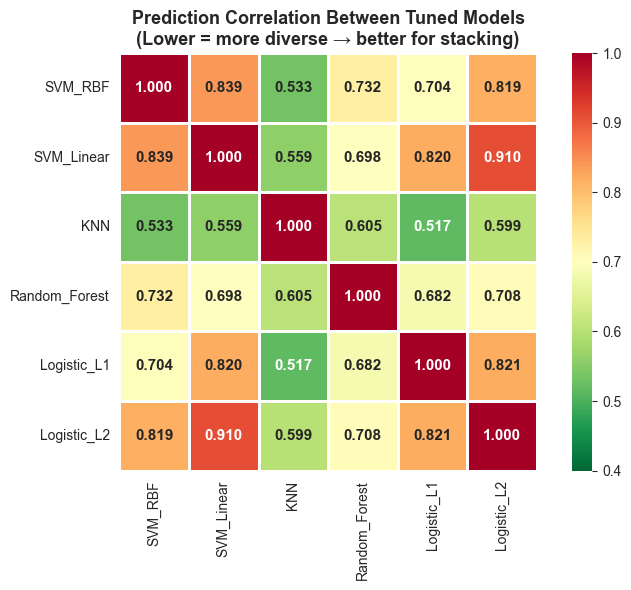


Models with lowest prediction correlation (most diverse) make the best stacking candidates.


In [14]:
# Prediction correlation analysis — are model errors uncorrelated?
# Aggregate predictions per model
pred_matrix = pd.DataFrame({
    name: np.concatenate(results['y_preds'])
    for name, results in nested_results.items()
})

pred_corr = pred_matrix.corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(pred_corr, annot=True, fmt='.3f', cmap='RdYlGn_r', center=0.7,
            square=True, linewidths=1, ax=ax, vmin=0.4, vmax=1.0,
            annot_kws={'size': 11, 'fontweight': 'bold'})
ax.set_title('Prediction Correlation Between Tuned Models\n(Lower = more diverse → better for stacking)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/prediction_correlation.png', bbox_inches='tight')
plt.show()

print('\nModels with lowest prediction correlation (most diverse) make the best stacking candidates.')

In [15]:
# Proposed stacking ensemble base learners (4 models from different families)
# Adjust based on your ranking and diversity analysis
STACKING_MODELS = ['SVM_RBF', 'KNN', 'Random_Forest', 'Logistic_L1']

print('Proposed base learners for stacking ensemble:')
for name in STACKING_MODELS:
    ba = nested_results[name]['mean_metrics']['balanced_accuracy']
    family = ranking_df[ranking_df['Model'] == name]['Family'].values[0]
    print(f'  {name} ({family}): BA = {ba:.4f}')

print(f'\nPrediction correlation between selected models:')
print(pred_corr.loc[STACKING_MODELS, STACKING_MODELS].round(3).to_string())

Proposed base learners for stacking ensemble:
  SVM_RBF (Kernel): BA = 0.6706
  KNN (Instance-based): BA = 0.7175
  Random_Forest (Tree Ensemble): BA = 0.6776
  Logistic_L1 (Linear (L1)): BA = 0.7368

Prediction correlation between selected models:
               SVM_RBF    KNN  Random_Forest  Logistic_L1
SVM_RBF          1.000  0.533          0.732        0.704
KNN              0.533  1.000          0.605        0.517
Random_Forest    0.732  0.605          1.000        0.682
Logistic_L1      0.704  0.517          0.682        1.000


## 11. Save Results

In [22]:
# Save tuned results
tuned_df.to_csv('../results/tuned_results.csv')
tuned_std_df.to_csv('../results/tuned_results_std.csv')
comparison_df.to_csv('../results/tuned_vs_untuned.csv')
ranking_df.to_csv('../results/model_ranking_tuned.csv', index=False)

# Save best params for each model (most common across folds)
best_params_summary = {}
for name, results in nested_results.items():
    params_df = pd.DataFrame(results['best_params'])
    most_common = {col: params_df[col].mode()[0] for col in params_df.columns}
    best_params_summary[name] = most_common

best_params_df = pd.DataFrame(best_params_summary).T
best_params_df.index.name = 'Model'
best_params_df.to_csv('../results/best_hyperparameters.csv')

print('Saved to results/:')
print('  tuned_results.csv')
print('  tuned_results_std.csv')
print('  tuned_vs_untuned.csv')
print('  model_ranking_tuned.csv')
print('  best_hyperparameters.csv')

print('\n--- Most Common Best Hyperparameters ---\n')
print(best_params_df.to_string())

Saved to results/:
  tuned_results.csv
  tuned_results_std.csv
  tuned_vs_untuned.csv
  model_ranking_tuned.csv
  best_hyperparameters.csv

--- Most Common Best Hyperparameters ---

              clf__C clf__gamma clf__metric clf__n_neighbors clf__weights clf__max_depth clf__min_samples_leaf clf__min_samples_split clf__n_estimators
Model                                                                                                                                                  
SVM_RBF        100.0      0.001         NaN              NaN          NaN            NaN                   NaN                    NaN               NaN
SVM_Linear       1.0        NaN         NaN              NaN          NaN            NaN                   NaN                    NaN               NaN
KNN              NaN        NaN   euclidean               15      uniform            NaN                   NaN                    NaN               NaN
Random_Forest    NaN        NaN         NaN              N

In [25]:
print("1 \n")
print(tuned_df.to_string())
print('\n--- Standard Deviations ---')
print(tuned_std_df.to_string())
print("2 \n")
print(comparison_df.to_string())
print("3 \n")
print(best_params_df.to_string())
print("4 \n")
print(ranking_df.to_string(index=False))

1 

               accuracy  balanced_accuracy  sensitivity  specificity  precision      f1     mcc  auc_roc
Model                                                                                                   
SVM_RBF          0.7112             0.6706       0.7579       0.5833     0.8447  0.7925  0.3118   0.8123
SVM_Linear       0.7512             0.7193       0.7719       0.6667     0.8824  0.8197  0.3920   0.8403
KNN              0.8211             0.7175       0.9184       0.5167     0.8595  0.8850  0.4267   0.9127
Random_Forest    0.7789             0.6776       0.8720       0.4833     0.8440  0.8546  0.3311   0.8862
Logistic_L1      0.7601             0.7368       0.7737       0.7000     0.8991  0.8236  0.4300   0.8710
Logistic_L2      0.7716             0.7558       0.7784       0.7333     0.9005  0.8298  0.4629   0.8671

--- Standard Deviations ---
               accuracy  balanced_accuracy  sensitivity  specificity  precision      f1     mcc  auc_roc
Model                 

## 12. Key Takeaways

Fill in after running:

1. **Nested CV produced more honest (and lower) estimates than NB03.** Most models saw slight declines in balanced accuracy, with SVM_RBF dropping the most (0.7956 → 0.6706, −12.5 points). This is not a failure of tuning — it reflects the removal of selection bias that was present in NB03 when we picked the 'best' configuration after seeing the results.
2. **Only Logistic_L2 (+0.013) and SVM_Linear (+0.017) improved with tuning.** These are the simplest models, suggesting that simpler models generalize better on this small dataset.

3. **Logistic_L2 is the best tuned model** with balanced accuracy of 0.7558 ± 0.1498 and the best sensitivity-specificity balance (0.778 / 0.733). Logistic_L1 is close behind at 0.7368 ± 0.1539.

4. **KNN has the highest sensitivity (0.918)** but poor specificity (0.517) — it catches nearly all PD cases but misclassifies half of healthy subjects.
5. **SVM_RBF dropped to last place (0.6706)**, likely because the aggressive tuning grid overfits the inner CV folds on this small dataset.
6. **Best hyperparameters**: SVM_RBF (C=100, gamma=0.001), SVM_Linear (C=1), KNN (k=15, uniform, euclidean), Random_Forest (max_depth=3, 50 trees — heavily regularized), Logistic_L1 (C=1), Logistic_L2 (C=0.1 — strong regularization).
7. **Random Forest selected strong regularization** (max_depth=3, min_samples_split=10) — the nested CV correctly penalizes overfitting on 195 samples.
8. **High variance across folds is a concern.** Specificity standard deviations range from 0.25 to 0.36, reflecting the fundamental challenge of having only ~8 healthy subjects. Some folds likely had very few healthy subjects in the test set, making specificity estimates noisy.
9. **Proposed base learners**: SVM_RBF (Kernel), KNN (Instance-based), Random_Forest (Tree Ensemble), Logistic_L1 (Linear) — four different model families.
10. **Prediction diversity is strong.** KNN has the lowest correlation with other models (0.517–0.605), making it particularly valuable for ensembling. SVM_Linear and Logistic_L2 are too correlated (0.910) to both include.
11. **The ensemble has potential** because the base learners make different kinds of errors: KNN excels at sensitivity, Logistic models at specificity, and the tree/kernel methods fall between.

**Next step**: Notebook 05 — Stacking Ensemble